# Phase 6 - Results

Pull everything into one place: the comparison table, the five figures I lean on most, the top features, and the per-category results.

In [1]:
import pickle
import pandas as pd
from IPython.display import Image, display, Markdown

compare = pd.read_csv("../outputs/comparison.csv")
per_cat = pd.read_csv("../outputs/per_category.csv")
with open("../outputs/rf_model.pkl", "rb") as f:
    rf = pickle.load(f)
print("loaded comparison.csv, per_category.csv, rf_model.pkl")

loaded comparison.csv, per_category.csv, rf_model.pkl


## Model comparison

In [2]:
compare

,model,test_mae,test_rmse,test_r2,cv_mae_mean,cv_mae_std
0,mean_baseline,74.95,93.75,-0.589,NaN,NaN
1,dow_baseline,75.19,93.24,-0.571,NaN,NaN
2,ridge,40.49,54.87,0.456,62.79,30.75
3,random_forest,39.37,54.50,0.463,66.50,37.17


## Five figures I lean on most

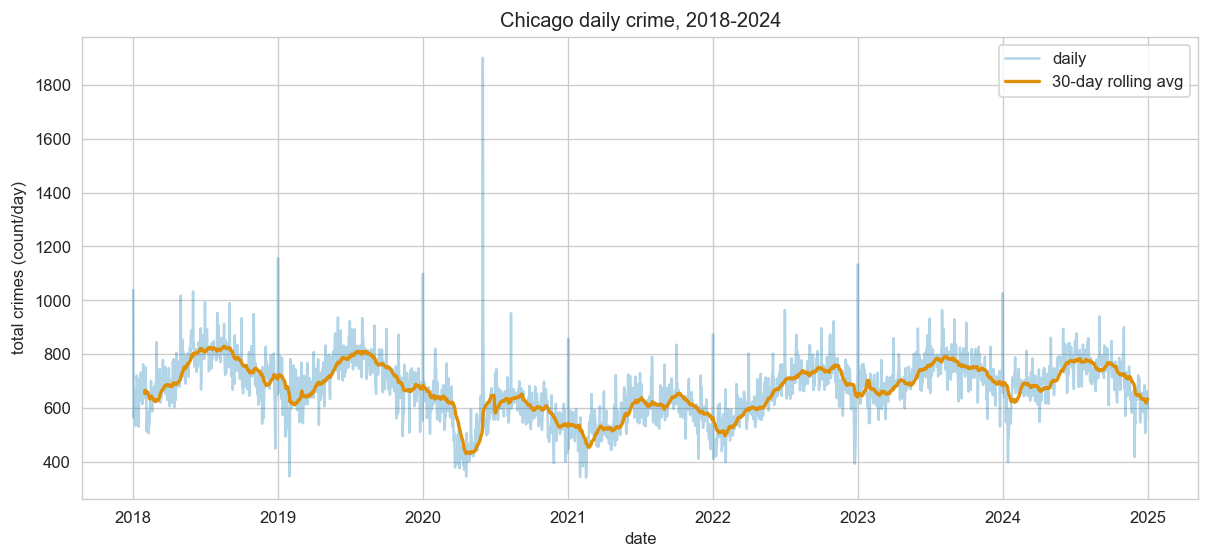

In [3]:
Image("../outputs/figures/fig_01_crime_timeseries.png")

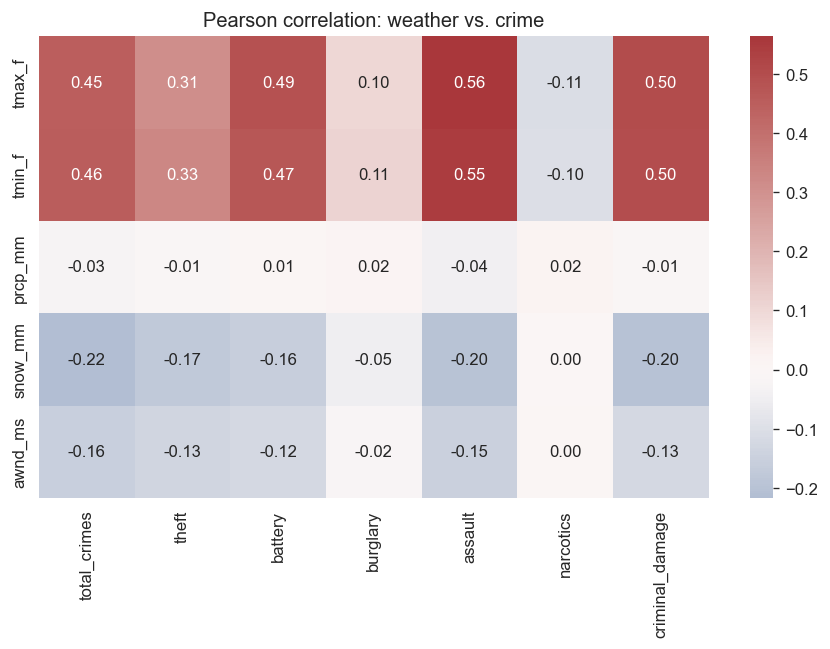

In [4]:
Image("../outputs/figures/fig_03_corr_heatmap.png")

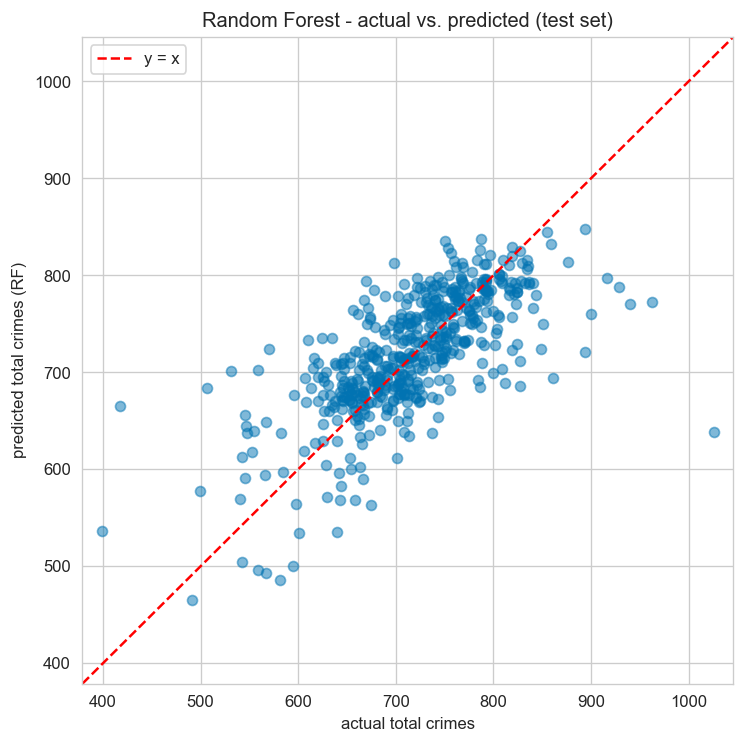

In [5]:
Image("../outputs/figures/fig_10_actual_vs_predicted.png")

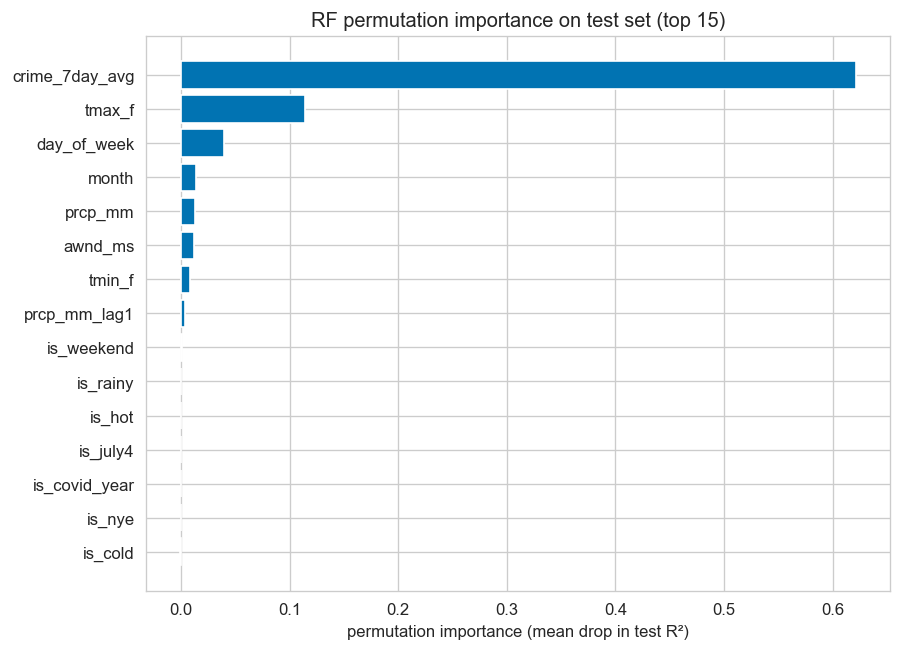

In [6]:
Image("../outputs/figures/fig_14_permutation_importance.png")

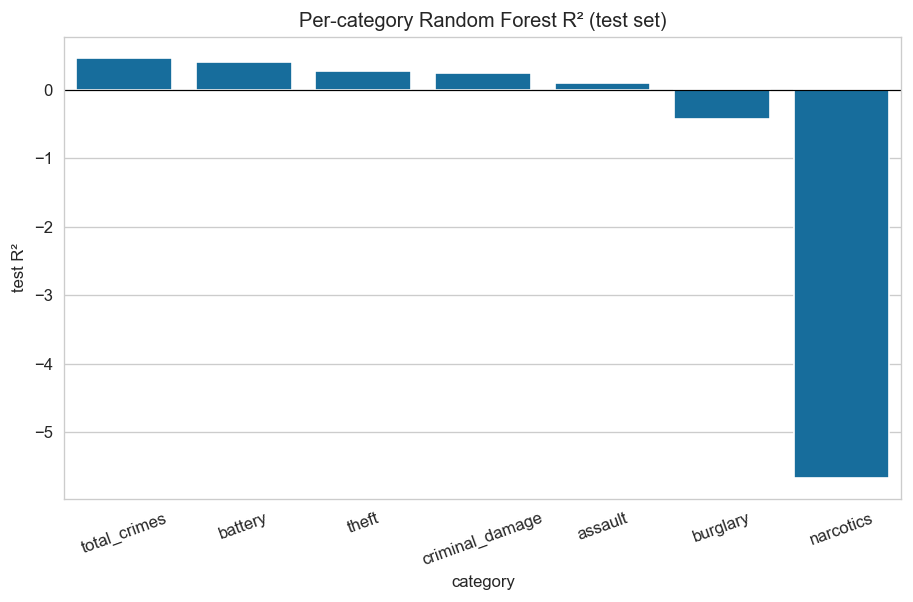

In [7]:
Image("../outputs/figures/fig_15_per_category_r2.png")

## Top 5 features (built-in importance)

In [8]:
feature_cols = ["tmax_f", "tmin_f", "prcp_mm", "awnd_ms",
                "day_of_week", "month", "is_weekend", "is_holiday",
                "is_rainy", "is_hot", "is_cold",
                "tmax_f_lag1", "prcp_mm_lag1", "crime_7day_avg",
                "is_covid_year", "is_nye", "is_july4"]
imp = pd.DataFrame({"feature": feature_cols, "importance": rf.feature_importances_})
imp.sort_values("importance", ascending=False).head(5).reset_index(drop=True)

,feature,importance
0,crime_7day_avg,0.791260
1,tmax_f,0.050321
2,awnd_ms,0.025599
3,tmin_f,0.024650
4,tmax_f_lag1,0.022814


## Per-category results

In [9]:
per_cat.sort_values("r2", ascending=False).reset_index(drop=True)

,category,r2,mae,rmse
0,total_crimes,0.463,39.37,54.50
1,battery,0.403,13.13,16.95
2,theft,0.269,17.00,21.76
3,criminal_damage,0.236,9.51,12.62
4,assault,0.090,8.48,10.68
5,burglary,-0.435,5.89,7.43
6,narcotics,-5.669,12.07,14.10


## Findings

- **Weather predicts crime, but not as much as recent-history does.** Random Forest gets test MAE = 39.4 and R² = 0.46. The single biggest feature is the 7-day rolling crime average (62% of permutation importance); TMAX comes in second at 11%. Weather features collectively contribute ~14%.
- **RF beats both baselines by ~47% on test MAE — well over the 5% bar.** RF and Ridge are statistically indistinguishable in CV (paired t-test on 5 folds: t = -0.77, p = 0.49), so the project's modeling story is more about beating the day-of-week baseline than picking between RF and Ridge.
- **Per-category sensitivity varies a lot.** Battery (R² = 0.40) and theft (0.27) fit reasonably. Burglary (-0.43) and especially narcotics (-5.67) don't, which reflects non-stationarity rather than weather independence alone.
- **Mean and day-of-week baselines have *negative* R² on the test set.** That's not a bug. The training mean (~659 crimes/day) sits below the test mean (~717 in 2023-2024); the train window includes the 2020 COVID dip and crime drifted upward in 2023-2024. It's a clean reminder that fixed-mean baselines fail on non-stationary time series.
- **Statistical tests support the EDA story.** Welch's t (rainy vs dry): p ≈ 5e-4. ANOVA across temp bins: F = 157.3, p ≈ 2e-120. Pearson r(TMAX, total_crimes) = 0.45, 95% CI [0.42, 0.48]. None of these are subtle.
- **The narcotics finding is the most interesting.** TMAX correlates *negatively* with narcotics (r = -0.11, p ≈ 5e-8), and the per-category model collapses on the test split. Almost certainly a policy or enforcement change between 2022 and 2023, not a weather effect.